# Classification: Logistic Regression & k-NN
## From Regression to Classification

Goals of this notebook:
- Understand binary classification problems
- Learn how logistic regression uses probabilities for classification
- Implement k-Nearest Neighbors (k-NN) algorithm
- Compare two fundamental classification approaches


In [6]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 4)
print('✓ Ready')

✓ Ready


---
# Part 1: Logistic Regression 

## The Classification Problem

**Regression vs Classification:**
- Regression: Predict continuous values (prices, temperatures)
- Classification: Predict discrete categories (spam/not spam, disease/healthy)

**Why not use linear regression for classification?**
Output unbounded → need probabilities between 0 and 1

## The Sigmoid Function: Converting to Probabilities

**Key Idea:** Transform linear output into probability

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Properties:**
- Input: any real number (-∞ to +∞)
- Output: probability (0 to 1)
- Smooth, differentiable (good for optimization)

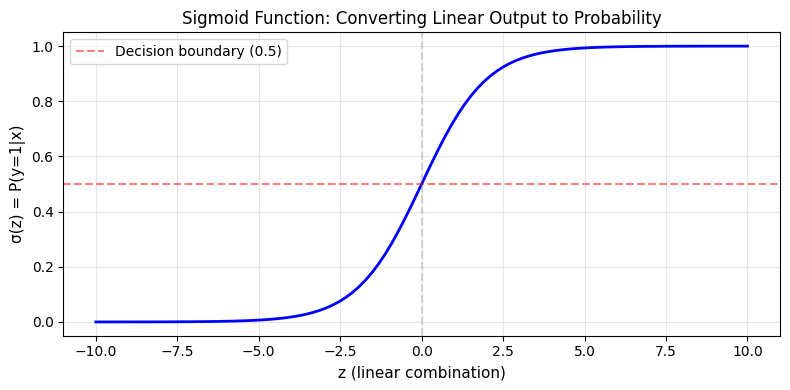

Key observations:
  When z=0  → σ(z)=0.50 (neutral)
  When z=2  → σ(z)=0.88 (likely class 1)
  When z=-2 → σ(z)=0.12 (likely class 0)


In [7]:
def sigmoid(z):
    """Sigmoid activation: maps any number to [0,1]"""
    return 1 / (1 + np.exp(-z))

# Visualize sigmoid
z_values = np.linspace(-10, 10, 100)
s_values = sigmoid(z_values)

plt.figure(figsize=(8, 4))
plt.plot(z_values, s_values, 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision boundary (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
plt.grid(alpha=0.3)
plt.xlabel('z (linear combination)', fontsize=11)
plt.ylabel('σ(z) = P(y=1|x)', fontsize=11)
plt.title('Sigmoid Function: Converting Linear Output to Probability', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print('Key observations:')
print(f'  When z=0  → σ(z)={sigmoid(0):.2f} (neutral)')
print(f'  When z=2  → σ(z)={sigmoid(2):.2f} (likely class 1)')
print(f'  When z=-2 → σ(z)={sigmoid(-2):.2f} (likely class 0)')

## Logistic Regression Model

**The Full Model:**
$$P(y=1|x) = \sigma(w_1 x + w_0) = \frac{1}{1 + e^{-(w_1 x + w_0)}}$$

**Decision Rule:**
- If P(y=1|x) ≥ 0.5 → predict class 1
- If P(y=1|x) < 0.5 → predict class 0

**Example:** Student exam pass/fail based on study hours

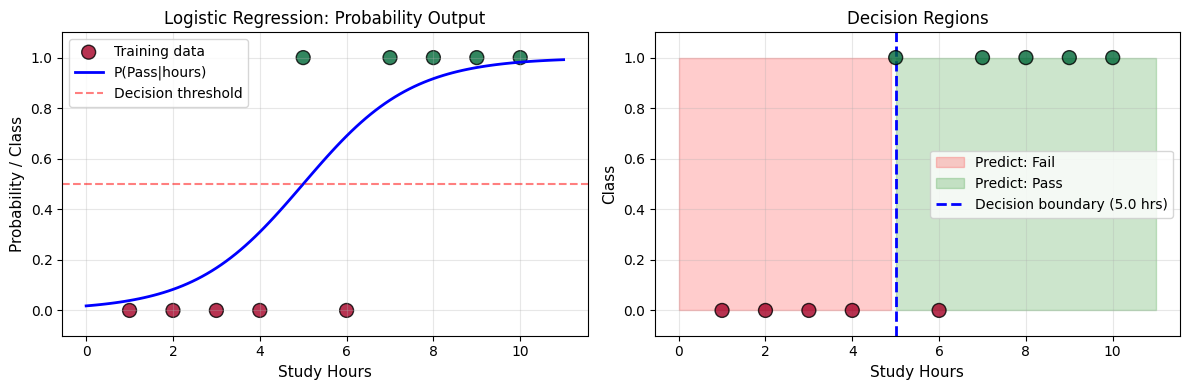


Model Interpretation:
  Decision boundary: 5.0 hours
  Study 3 hrs → P(Pass)=0.168 → Predict: Fail
  Study 6 hrs → P(Pass)=0.690 → Predict: Pass
  Study 9 hrs → P(Pass)=0.961 → Predict: Pass


In [8]:
# Generate synthetic data: Study hours vs Pass/Fail
np.random.seed(42)
X_train = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # study hours
y_train = np.array([0, 0, 0, 0, 1, 0, 1, 1, 1, 1])    # 0=fail, 1=pass

# Simple optimization: gradient descent (simplified)
# For teaching purposes, we use approximate optimal parameters
w1_opt = 0.8   # slope: more hours → higher probability
w0_opt = -4.0  # intercept: shifts decision boundary

def predict_proba(x, w1, w0):
    """Predict probability P(y=1|x)"""
    z = w1 * x + w0
    return sigmoid(z)

def predict_class(x, w1, w0, threshold=0.5):
    """Predict class (0 or 1)"""
    return (predict_proba(x, w1, w0) >= threshold).astype(int)

# Visualize
x_plot = np.linspace(0, 11, 100)
prob_plot = predict_proba(x_plot, w1_opt, w0_opt)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Data + Probability Curve
ax1.scatter(X_train, y_train, s=100, c=y_train, cmap='RdYlGn', 
            edgecolors='black', alpha=0.8, label='Training data')
ax1.plot(x_plot, prob_plot, 'b-', linewidth=2, label='P(Pass|hours)')
ax1.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision threshold')
ax1.set_xlabel('Study Hours', fontsize=11)
ax1.set_ylabel('Probability / Class', fontsize=11)
ax1.set_title('Logistic Regression: Probability Output', fontsize=12)
ax1.grid(alpha=0.3)
ax1.legend()
ax1.set_ylim([-0.1, 1.1])

# Plot 2: Decision Regions
predictions = predict_class(x_plot, w1_opt, w0_opt)
ax2.fill_between(x_plot, 0, 1, where=(predictions==0), alpha=0.2, color='red', label='Predict: Fail')
ax2.fill_between(x_plot, 0, 1, where=(predictions==1), alpha=0.2, color='green', label='Predict: Pass')
ax2.scatter(X_train, y_train, s=100, c=y_train, cmap='RdYlGn', 
            edgecolors='black', alpha=0.8, zorder=3)
decision_boundary = -w0_opt / w1_opt
ax2.axvline(x=decision_boundary, color='blue', linestyle='--', linewidth=2, 
            label=f'Decision boundary ({decision_boundary:.1f} hrs)')
ax2.set_xlabel('Study Hours', fontsize=11)
ax2.set_ylabel('Class', fontsize=11)
ax2.set_title('Decision Regions', fontsize=12)
ax2.set_ylim([-0.1, 1.1])
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nModel Interpretation:')
print(f'  Decision boundary: {decision_boundary:.1f} hours')
print(f'  Study 3 hrs → P(Pass)={predict_proba(3, w1_opt, w0_opt):.3f} → Predict: Fail')
print(f'  Study 6 hrs → P(Pass)={predict_proba(6, w1_opt, w0_opt):.3f} → Predict: Pass')
print(f'  Study 9 hrs → P(Pass)={predict_proba(9, w1_opt, w0_opt):.3f} → Predict: Pass')

---
# Part 2: k-Nearest Neighbors (k-NN)

## A Different Approach: Learn from Similar Examples

**Core Idea:** *"You are the average of your k closest neighbors"*

**Algorithm (Classification):**
1. Find the k training samples closest to new point
2. Count votes from these k neighbors
3. Assign the majority class

**Key Parameter:**
- **k=1**: Very sensitive (memorization)
- **k=large**: Very smooth (may ignore local patterns)
- **k=moderate**: Balance between flexibility and generalization

In [9]:
def euclidean_distance(x1, x2):
    """Calculate distance between two points"""
    return np.sqrt(np.sum((x1 - x2)**2))

def knn_predict(X_train, y_train, x_new, k=3):
    """
    k-NN prediction for a single point
    
    How it works:
    1. Calculate distances from x_new to all training points
    2. Find indices of k smallest distances
    3. Get labels of k nearest neighbors
    4. Return majority vote (most common label)
    """
    # Step 1: Calculate all distances
    distances = [euclidean_distance(x_new, x) for x in X_train]
    
    # Step 2: Find k nearest neighbors
    k_indices = np.argsort(distances)[:k]
    
    # Step 3: Get their labels
    k_nearest_labels = y_train[k_indices]
    
    # Step 4: Majority vote
    prediction = np.bincount(k_nearest_labels).argmax()
    
    return prediction, k_indices

print('✓ k-NN function defined')

✓ k-NN function defined


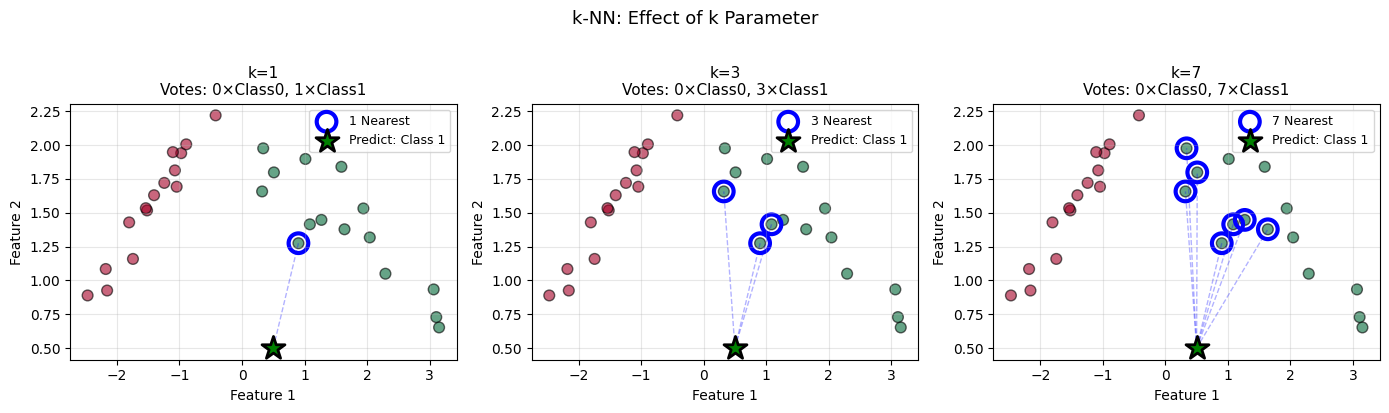


Observations:
  k=1: Uses only closest point (can be unstable)
  k=3: Considers local neighborhood (balanced)
  k=7: Smoother decision (more robust to outliers)


In [5]:
# Generate 2D classification dataset
X_2d, y_2d = make_classification(
    n_samples=30, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, random_state=42, class_sep=1.5
)

# Example: classify a new point
x_new = np.array([0.5, 0.5])

# Compare k=1, k=3, k=7
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
k_values = [1, 3, 7]

for ax, k in zip(axes, k_values):
    pred, neighbor_idx = knn_predict(X_2d, y_2d, x_new, k=k)
    
    # Plot all training data
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap='RdYlGn', 
               s=60, alpha=0.6, edgecolors='black')
    
    # Highlight k-nearest neighbors
    ax.scatter(X_2d[neighbor_idx, 0], X_2d[neighbor_idx, 1], 
               s=200, facecolors='none', edgecolors='blue', 
               linewidths=3, label=f'{k} Nearest')
    
    # Plot new point
    color = 'green' if pred == 1 else 'red'
    ax.scatter(x_new[0], x_new[1], s=300, marker='*', 
               c=color, edgecolors='black', linewidths=2, 
               label=f'Predict: Class {pred}', zorder=5)
    
    # Draw lines to neighbors
    for idx in neighbor_idx:
        ax.plot([x_new[0], X_2d[idx, 0]], 
                [x_new[1], X_2d[idx, 1]], 
                'b--', alpha=0.3, linewidth=1)
    
    neighbor_classes = y_2d[neighbor_idx]
    votes = f'Votes: {np.sum(neighbor_classes==0)}×Class0, {np.sum(neighbor_classes==1)}×Class1'
    ax.set_title(f'k={k}\n{votes}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('k-NN: Effect of k Parameter', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nObservations:')
print('  k=1: Uses only closest point (can be unstable)')
print('  k=3: Considers local neighborhood (balanced)')
print('  k=7: Smoother decision (more robust to outliers)')

## Quick Comparison: Logistic Regression vs k-NN

| Aspect | Logistic Regression | k-NN |
|--------|-------------------|------|
| **Approach** | Learn parameters (w₁, w₀) | Memorize training data |
| **Training** | Optimize parameters | Store all data points |
| **Prediction** | Fast (evaluate function) | Slow (compute distances) |
| **Decision Boundary** | Linear (straight line) | Non-linear (flexible) |
| **Interpretability** | High (clear coefficients) | Low (no explicit model) |
| **Pros** | Simple, fast, probabilistic | No training, handles complex patterns |
| **Cons** | Assumes linear boundary | Slow for large datasets, memory-heavy |

**When to use what?**
- **Logistic Regression**: Linear relationships, need probabilities, large datasets
- **k-NN**: Non-linear patterns, small datasets, quick prototyping

---
## Key Takeaways

**Logistic Regression:**
1. Uses sigmoid function: $\sigma(z) = \frac{1}{1+e^{-z}}$ to convert linear output to probability
2. Outputs P(y=1|x) ∈ [0,1]
3. Decision boundary: where P(y=1|x) = 0.5
4. Parametric model: learns fixed parameters (w₁, w₀)

**k-NN:**
1. Instance-based: no training phase, stores all data
2. Prediction: find k closest neighbors, take majority vote
3. Parameter k controls complexity: small k → complex, large k → simple
4. Non-parametric: decision boundary determined by training data

